In [1]:
import sys
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

PROJECT_ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data" / "raw").exists()
)
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from evaluate import evaluate
from features import FEATURES, GROUP, TARGET, load_rated, make_splits
from models import fit_predict_type, make_logreg

rated = load_rated()
train, valid, test = make_splits(rated)
dev = pd.concat([train, valid]).reset_index(drop=True)
print(f"Development (train + valid): {len(dev):,}   Test: {len(test):,}")

Development (train + valid): 57,112   Test: 14,278


In [2]:
# Train the chosen model on ALL development data
final_model = make_logreg().fit(dev[FEATURES], dev[TARGET])

# Score the test set: the first and only time it is used
final_score = final_model.predict_proba(test[FEATURES])[:, 1]

rng = np.random.default_rng(0)
test_results = pd.DataFrame([
    evaluate("Random order", test, rng.random(len(test))),
    evaluate("Business type only", test, fit_predict_type(dev, test)),
    evaluate("Logistic regression (final)", test, final_score),
])
print("FINAL RESULTS ON THE LOCKED TEST SET\n")
print(test_results.round(3).to_string(index=False))

FINAL RESULTS ON THE LOCKED TEST SET

                      model  recall@20%  recall@10%  PR-AUC (within)  PR-AUC (pooled)  ROC-AUC (pooled)
               Random order       0.190       0.082            0.062            0.054             0.486
         Business type only       0.326       0.165            0.078            0.079             0.635
Logistic regression (final)       0.393       0.231            0.127            0.157             0.752


In [3]:
# The same result in plain numbers: inspect the top 20% of each borough's list
scored = test.assign(score=final_score)
inspected = found = 0
for _, borough in scored.groupby(GROUP):
    k = int(np.ceil(0.2 * len(borough)))
    inspected += k
    found += borough.nlargest(k, "score")[TARGET].sum()

total_fails = int(test[TARGET].sum())
print(f"Test set: {len(test):,} businesses, {total_fails:,} of them failing.")
print(f"Inspecting the top 20% of each borough's list = {inspected:,} inspections")
print(f"   finds {found:,} of the {total_fails:,} failing businesses ({found / total_fails:.1%}).")
print(f"   Random inspections of the same number would find about {0.2 * total_fails:,.0f}.")

Test set: 14,278 businesses, 801 of them failing.
Inspecting the top 20% of each borough's list = 2,868 inspections
   finds 315 of the 801 failing businesses (39.3%).
   Random inspections of the same number would find about 160.


In [4]:
model_path = PROJECT_ROOT / "models" / "logreg_final.joblib"
joblib.dump(final_model, model_path)
print("Saved to", model_path)

# Check it loads back and gives identical scores
reloaded = joblib.load(model_path)
same = np.allclose(reloaded.predict_proba(test[FEATURES])[:, 1], final_score)
print("Reloaded model gives identical scores:", same)

Saved to c:\projects\food-hygiene-risk-london\models\logreg_final.joblib
Reloaded model gives identical scores: True


## Final result (locked test set, used once)

| Model | recall@20% | recall@10% | PR-AUC (within) |
|---|---|---|---|
| Random order | 0.190 | 0.082 | 0.062 |
| Business type only | 0.326 | 0.165 | 0.078 |
| **Logistic regression (final)** | **0.393** | **0.231** | **0.127** |

- Consistent with cross-validation (recall@20% 0.407-0.415, recall@10% 0.235,
  PR-AUC within 0.130-0.133). The small drop is within normal variation: no overfitting.
- Beats the business-type baseline by +0.067 (recall@20%) and +0.066 (recall@10%).
- **In counts:** 14,278 test businesses, 801 failing. Inspecting the top 20% of each
  borough's list (2,868 inspections) finds **315** failing businesses vs about **160**
  by random selection.
- **Hit rate doubles:** about 1 in 9 model-guided inspections finds a failing business,
  vs about 1 in 18 at random.
- Final model saved to `models/logreg_final.joblib` (reload check: identical scores).

In [5]:
import matplotlib.pyplot as plt

from features import CATEGORICAL
from models import OTHER_NUMERIC, SKEWED

prep = final_model.named_steps["prep"]
coefs = final_model.named_steps["model"].coef_[0]

# Column names in the order the preprocessing step outputs them:
# one-hot categories first, then the log-scaled columns, then the scaled columns
onehot_names = prep.named_transformers_["categories"].get_feature_names_out(CATEGORICAL)
n_cat = len(onehot_names)

# --- Categorical: compare each category with the AVERAGE category of its column
cats = pd.DataFrame({"name": onehot_names, "coef": coefs[:n_cat]})
cats["column"] = [next(c for c in CATEGORICAL if n.startswith(c + "_")) for n in cats["name"]]
cats["label"] = [n[len(c) + 1:] for n, c in zip(cats["name"], cats["column"])]
cats["coef"] = cats["coef"] - cats.groupby("column")["coef"].transform("mean")

# --- Numeric: flip deprivation ranks so the effect reads "per 1 SD MORE deprived"
nums = pd.DataFrame({"label": SKEWED + OTHER_NUMERIC, "coef": coefs[n_cat:]})
flip = nums["label"].str.endswith("_rank")
nums.loc[flip, "coef"] = -nums.loc[flip, "coef"]
nums.loc[flip, "label"] = nums.loc[flip, "label"].str.replace("_rank", "") + " (more deprived)"

for part in (cats, nums):
    part["odds_ratio"] = np.exp(part["coef"])

print("Business types (odds of failing vs the average business type):\n")
print(cats[cats["column"] == "BusinessType"].sort_values("odds_ratio", ascending=False)
      [["label", "odds_ratio"]].round(2).to_string(index=False))
print("\nNumeric features (odds ratio per 1 standard deviation increase):\n")
print(nums.sort_values("odds_ratio", ascending=False)[["label", "odds_ratio"]].round(2).to_string(index=False))

Business types (odds of failing vs the average business type):

                                label  odds_ratio
                    Retailers - other        2.24
               Takeaway/sandwich shop        2.02
              Restaurant/Cafe/Canteen        1.60
            Distributors/Transporters        1.46
                       Mobile caterer        1.27
                Manufacturers/packers        1.25
Retailers - supermarkets/hypermarkets        1.20
                  Importers/Exporters        1.13
                    Pub/bar/nightclub        1.08
                      Farmers/growers        0.95
              Other catering premises        0.90
    Hotel/bed & breakfast/guest house        0.63
                      Caring Premises        0.43
            School/college/university        0.18

Numeric features (odds ratio per 1 standard deviation increase):

                           label  odds_ratio
             imd (more deprived)        1.19
                     pop_dens

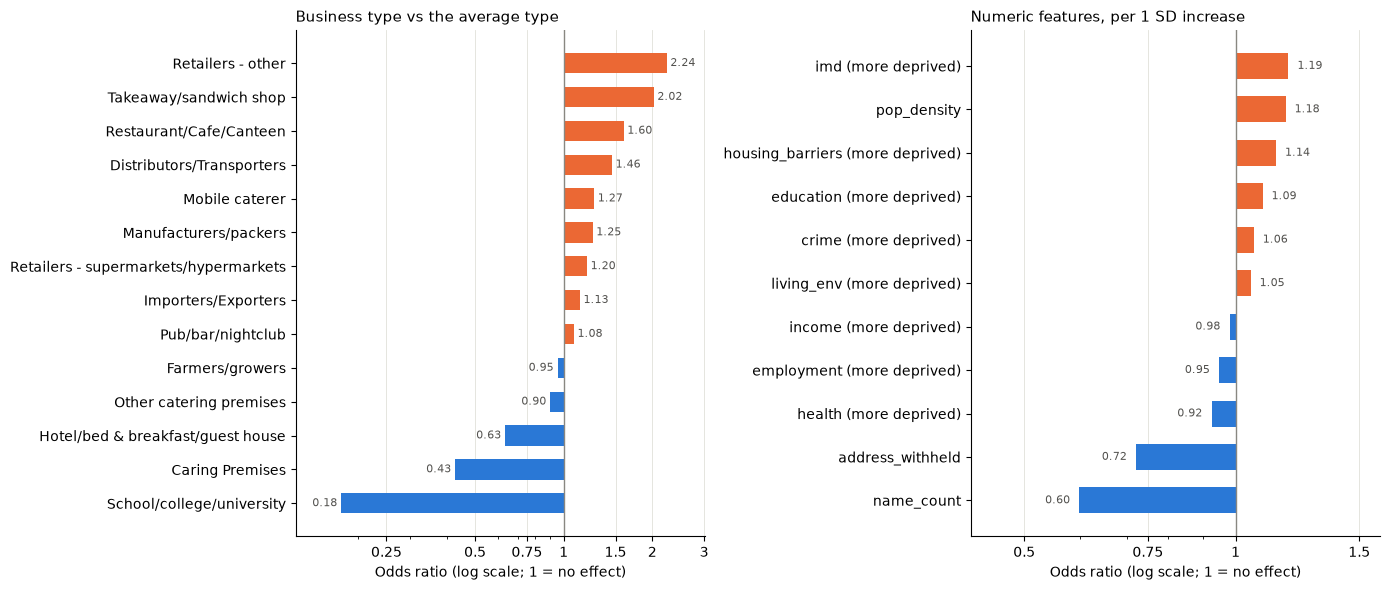

In [6]:
from matplotlib.ticker import FuncFormatter, NullFormatter

RISK_UP, RISK_DOWN = "#eb6834", "#2a78d6"   # orange = raises risk, blue = lowers it
INK, MUTED, GRID = "#52514e", "#898781", "#e1e0d9"


def plot_odds(ax, frame, title):
    frame = frame.sort_values("odds_ratio")
    colors = [RISK_UP if v > 1 else RISK_DOWN for v in frame["odds_ratio"]]
    ax.barh(frame["label"], frame["odds_ratio"] - 1, left=1, color=colors, height=0.6)
    ax.axvline(1, color=MUTED, linewidth=1)
    ax.set_xscale("log")
    for y, v in enumerate(frame["odds_ratio"]):
        ax.text(v * (1.03 if v > 1 else 0.97), y, f"{v:.2f}", va="center",
                ha="left" if v > 1 else "right", fontsize=8, color=INK)
    lo = min(frame["odds_ratio"].min(), 1) * 0.7
    hi = max(frame["odds_ratio"].max(), 1) * 1.35
    ax.set_xlim(lo, hi)
    ax.set_xticks([t for t in [0.25, 0.5, 0.75, 1, 1.5, 2, 3, 4] if lo <= t <= hi])
    ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}"))
    ax.xaxis.set_minor_formatter(NullFormatter())
    ax.set_title(title, loc="left", fontsize=11)
    ax.set_xlabel("Odds ratio (log scale; 1 = no effect)")
    ax.grid(axis="x", color=GRID, linewidth=0.6)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)


types = cats[cats["column"] == "BusinessType"]
fig, (left, right) = plt.subplots(1, 2, figsize=(14, 6))
plot_odds(left, types, "Business type vs the average type")
plot_odds(right, nums, "Numeric features, per 1 SD increase")
plt.tight_layout()
plt.show()

## What the model learned (odds ratios)

**Business types** (vs the average type): Retailers - other 2.24, Takeaway 2.02,
Restaurant 1.60 ... Hotels 0.63, Caring premises 0.43, Schools 0.18.
Same order as the EDA (Q1).

**Two informative differences from the raw rates:**
- Supermarkets: raw rate 2.6% (low), but odds ratio 1.20 (above average). Their low
  raw rate is explained by being chains (`name_count`), not by being supermarkets.
- Mobile caterers: raw rate 3.2% (low), but odds ratio 1.27. Their low raw rate is
  explained by withheld (home-based) addresses (61% withheld; listed-address mobile
  caterers fail at 5.3%, see Q4).
- Lesson: raw rates can mislead because each factor partly stands in for others.

**Numeric features** (per 1 standard deviation):
- Chain size (`name_count`, log): 0.60, the strongest protective factor (matches Q5).
- `address_withheld`: 0.72 per SD, which is about **0.34 for withheld vs listed**.
  This matches the Q4 business-type-adjusted ratio of 0.36 from a different method.
- Population density: 1.18 (matches Q3: its signal is not tangled with council strictness).
- Deprivation: domains split the credit because they are highly correlated (some
  above 1, some slightly below). Interpreted as a group: about 1.4x the odds when an area
  is 1 SD more deprived across all domains. Do not interpret individual domains.

**Conclusion:** the model's learned effects agree with the EDA findings, which gives
confidence it has learned real patterns rather than noise.

In [7]:
def inspection_table(data, score, top=0.2):
    """Per within-borough deprivation fifth: where businesses, failures and inspections are."""
    frame = data[[GROUP, TARGET, "imd_rank"]].copy()
    frame["score"] = score

    # 1 = most deprived fifth of THAT borough's businesses, 5 = least deprived
    frame["fifth"] = frame.groupby(GROUP)["imd_rank"].transform(
        lambda r: pd.qcut(r.rank(method="first"), 5, labels=False) + 1
    )
    # Inspected = in the top `top` share of its own borough's risk list
    rank_in_borough = frame.groupby(GROUP)["score"].rank(ascending=False, method="first")
    borough_size = frame.groupby(GROUP)["score"].transform("size")
    frame["inspected"] = rank_in_borough <= np.ceil(top * borough_size)
    frame["found"] = frame["inspected"] & (frame[TARGET] == 1)

    out = frame.groupby("fifth").agg(
        businesses=(TARGET, "size"),
        failures=(TARGET, "sum"),
        inspections=("inspected", "sum"),
        found=("found", "sum"),
    )
    out["share_businesses"] = out["businesses"] / out["businesses"].sum()
    out["share_failures"] = out["failures"] / out["failures"].sum()
    out["share_inspections"] = out["inspections"] / out["inspections"].sum()
    out["hit_rate"] = out["found"] / out["inspections"]
    out["share_of_its_failures_found"] = out["found"] / out["failures"]
    return out


pct = "{:.1%}".format
cols = ["share_businesses", "share_failures", "share_inspections", "hit_rate",
        "share_of_its_failures_found"]
final_fair = inspection_table(test, final_score)
print("Final model, test set. Fifth 1 = most deprived fifth of each borough\n")
print(final_fair[cols].to_string(formatters={c: pct for c in cols}))

Final model, test set. Fifth 1 = most deprived fifth of each borough

      share_businesses share_failures share_inspections hit_rate share_of_its_failures_found
fifth                                                                                       
1                20.1%          29.0%             43.5%    11.9%                       63.8%
2                20.0%          21.2%             28.1%    12.0%                       57.1%
3                19.9%          19.7%             15.5%     9.0%                       25.3%
4                20.0%          15.9%             10.0%     8.0%                       18.1%
5                20.0%          14.2%              2.9%     8.5%                        6.1%


In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

# Same model, but WITHOUT the 8 deprivation ranks
NO_DEP_NUMERIC = [c for c in OTHER_NUMERIC if not c.endswith("_rank")]
no_dep_features = CATEGORICAL + SKEWED + NO_DEP_NUMERIC

no_dep_model = Pipeline([
    ("prep", ColumnTransformer([
        ("categories", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL),
        ("log_scaled", make_pipeline(FunctionTransformer(np.log1p), StandardScaler()), SKEWED),
        ("scaled", StandardScaler(), NO_DEP_NUMERIC),
    ])),
    ("model", LogisticRegression(class_weight="balanced", max_iter=2000)),
]).fit(dev[no_dep_features], dev[TARGET])
no_dep_score = no_dep_model.predict_proba(test[no_dep_features])[:, 1]

print("Overall performance on the test set:\n")
print(pd.DataFrame([
    evaluate("Final model (with deprivation)", test, final_score),
    evaluate("Same model, no deprivation", test, no_dep_score),
])[["model", "recall@20%", "recall@10%", "PR-AUC (within)"]].round(3).to_string(index=False))

no_dep_fair = inspection_table(test, no_dep_score)
print("\nShare of inspections sent to each fifth (1 = most deprived):\n")
print(pd.DataFrame({
    "share_businesses": final_fair["share_businesses"],
    "share_failures": final_fair["share_failures"],
    "with_deprivation": final_fair["share_inspections"],
    "no_deprivation": no_dep_fair["share_inspections"],
}).to_string(formatters={c: pct for c in ["share_businesses", "share_failures", "with_deprivation", "no_deprivation"]}))

Overall performance on the test set:

                         model  recall@20%  recall@10%  PR-AUC (within)
Final model (with deprivation)       0.393       0.231            0.127
    Same model, no deprivation       0.389       0.221            0.113

Share of inspections sent to each fifth (1 = most deprived):

      share_businesses share_failures with_deprivation no_deprivation
fifth                                                                
1                20.1%          29.0%            43.5%          29.5%
2                20.0%          21.2%            28.1%          22.7%
3                19.9%          19.7%            15.5%          16.5%
4                20.0%          15.9%            10.0%          16.7%
5                20.0%          14.2%             2.9%          14.7%


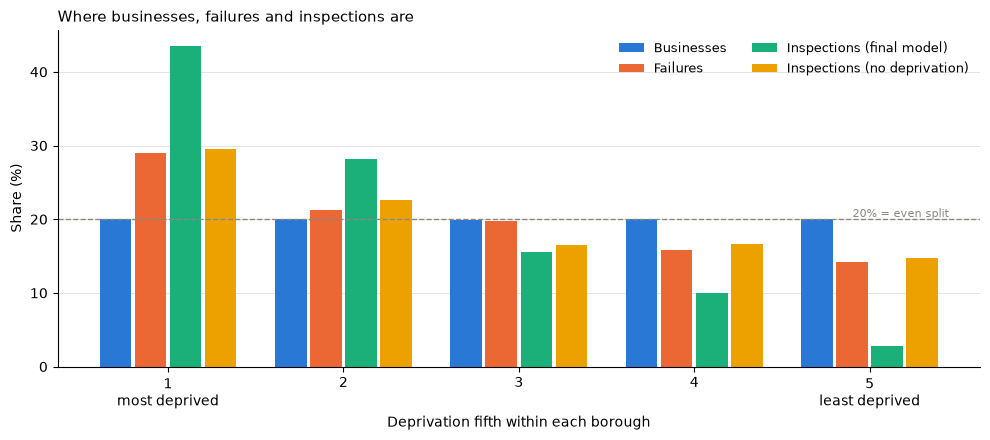

In [9]:
series = {
    "Businesses": (final_fair["share_businesses"], "#2a78d6"),
    "Failures": (final_fair["share_failures"], "#eb6834"),
    "Inspections (final model)": (final_fair["share_inspections"], "#1baf7a"),
    "Inspections (no deprivation)": (no_dep_fair["share_inspections"], "#eda100"),
}
x = np.arange(1, 6)
width = 0.2

fig, ax = plt.subplots(figsize=(10, 4.5))
for i, (label, (values, color)) in enumerate(series.items()):
    ax.bar(x + (i - 1.5) * width, values * 100, width=width * 0.9, color=color, label=label)
ax.axhline(20, color=MUTED, linestyle="--", linewidth=1)
ax.text(5.45, 20.3, "20% = even split", color=MUTED, fontsize=8, ha="right")
ax.set_xticks(x, ["1\nmost deprived", "2", "3", "4", "5\nleast deprived"])
ax.set_xlabel("Deprivation fifth within each borough")
ax.set_ylabel("Share (%)")
ax.set_title("Where businesses, failures and inspections are", loc="left", fontsize=11)
ax.legend(frameon=False, ncols=2, fontsize=9)
ax.grid(axis="y", color=GRID, linewidth=0.6)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
plt.tight_layout()
plt.show()

In [10]:
from sklearn.model_selection import StratifiedKFold

from models import fit_predict_logreg

MAX_COST = 0.02   # decided BEFORE running: switch if removing deprivation costs less than this

strata = dev[GROUP] + "_" + dev[TARGET].astype(str)
rows = []
for seed in (42, 7):                      # both fold sets used earlier: 10 comparisons
    folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    for fold, (fit_idx, score_idx) in enumerate(folds.split(dev, strata), start=1):
        fit_part, score_part = dev.iloc[fit_idx], dev.iloc[score_idx]
        for use_dep, name in [(True, "with deprivation"), (False, "no deprivation")]:
            score = fit_predict_logreg(fit_part, score_part, use_deprivation=use_dep)
            row = evaluate(name, score_part, score)
            row.update(seed=seed, fold=fold)
            rows.append(row)
    print(f"Fold set {seed} done")

check = pd.DataFrame(rows)
metrics = ["recall@20%", "recall@10%", "PR-AUC (within)"]
print("\nMean and std over 10 folds (development data only):\n")
print(check.groupby("model")[metrics].agg(["mean", "std"]).round(3).to_string())

paired = check.pivot_table(index=["seed", "fold"], columns="model", values="recall@20%")
paired["cost"] = paired["with deprivation"] - paired["no deprivation"]
print("\nrecall@20% per fold (cost = with minus without):\n")
print(paired.round(3).to_string())

mean_cost = paired["cost"].mean()
print(f"\nMean recall@20% cost of removing deprivation: {mean_cost:+.3f}")
print(f"Rule (cost below {MAX_COST}):",
      "SWITCH to the no-deprivation model" if mean_cost < MAX_COST else "cost too high, keep deprivation")

Fold set 42 done
Fold set 7 done

Mean and std over 10 folds (development data only):

                 recall@20%        recall@10%        PR-AUC (within)       
                       mean    std       mean    std            mean    std
model                                                                      
no deprivation        0.387  0.019      0.223  0.018           0.121  0.008
with deprivation      0.411  0.023      0.234  0.013           0.132  0.011

recall@20% per fold (cost = with minus without):

model      no deprivation  with deprivation   cost
seed fold                                         
7    1              0.419             0.422  0.003
     2              0.370             0.401  0.031
     3              0.406             0.428  0.023
     4              0.402             0.432  0.030
     5              0.363             0.391  0.029
42   1              0.380             0.438  0.058
     2              0.375             0.380  0.006
     3              0.3

## Fairness check: where does the model send inspectors?

Measured on the test set, within each borough (fifth 1 = most deprived fifth of that
borough's businesses), inspecting the top 20% of each borough's list.

| Fifth | Share of failures | Inspections (with deprivation) | Inspections (no deprivation) |
|---|---|---|---|
| 1 (most deprived) | 29.0% | **43.5%** | 29.5% |
| 2 | 21.2% | 28.1% | 22.7% |
| 3 | 19.7% | 15.5% | 16.5% |
| 4 | 15.9% | 10.0% | 16.7% |
| 5 (least deprived) | 14.2% | **2.9%** | 14.7% |

- **The deprivation model over-targets deprived areas:** 43.5% of inspections go to the
  most deprived fifth, which holds 29% of failures. The least deprived fifth holds 14.2%
  of failures but gets 2.9% of inspections, and only **6.1%** of its failures are found.
- Hit rates are similar across fifths (8-12%), so the issue is coverage, not wasted visits.
- **Why:** ranking amplifies small differences. Failures are about 2x more common in the
  most vs least deprived fifth, but taking the top 20% turns that into about a 15x
  difference in inspections.
- **Without deprivation features, inspections track failures almost exactly.**

### Cost of removing deprivation (cross-validation, 10 paired folds, development data only)
- recall@20%: 0.411 with vs 0.387 without, a cost of **0.024**, lower on all 10 folds.
- The test set alone suggested only 0.004; a single split understated the cost.
- Pre-registered rule (switch if cost < 0.02): **not met, so deprivation stays in the
  default model.**

### Decision
This is a policy trade-off (about 6% fewer failures found vs proportional coverage across
neighbourhoods), not a technical one. The dashboard uses the **deprivation model by default**
and offers a **toggle to the no-deprivation model**, showing the trade-off next to it, so
the council makes the choice.

### Limitation
Failures are recorded by human inspectors. If deprived areas are scored more harshly,
the "share of failures" itself would be inflated there. This cannot be measured from
this data.